In [3]:
import MDAnalysis as mda
import numpy as np
from collections import Counter


In [4]:
%cd ./check_Gauche_Sage2.2.0-alkanes-filtered
%pwd

/media/julianne/DATA/Lipids/Shirts_2023/helpful_code/check_Gauche_Sage2.2.0-alkanes-filtered


'/media/julianne/DATA/Lipids/Shirts_2023/helpful_code/check_Gauche_Sage2.2.0-alkanes-filtered'

In [5]:
mol = 'pentadecane'
u = mda.Universe(f"npt2_{mol}_liquid.gro", f"npt2_{mol}_liquid.xtc")

In [6]:
from MDAnalysis.analysis.dihedrals import Dihedral

def classify_dihedral(angle_deg):
    """Classify a dihedral angle into conformers based on standard cutoffs."""
    if 90 < angle_deg <= 180 or -180 <= angle_deg < -90: #notice in MDAnalysis, the trans is 180 degrees 
        return "trans"
    elif 30 < angle_deg <= 90 or -90 <= angle_deg < -30: # gauche is 60 degrees 
        return "gauche"
    else:
        return "gauche" 

# Select all non-hydrogen atoms in residue 1 of alkane
alkane_atoms = u.select_atoms("resid 1 and resname ALK and not name H*")

# Ensure the atoms are ordered properly (assumes topology ordering matches connectivity)
dihedral_ag_list = []

# Create overlapping 4-atom groups
for i in range(len(alkane_atoms) - 3):
    atom_group = u.atoms[[alkane_atoms[i].index,
                          alkane_atoms[i+1].index,
                          alkane_atoms[i+2].index,
                          alkane_atoms[i+3].index]]
    dihedral_ag_list.append(atom_group)

# Run Dihedral analysis
dih_analysis = Dihedral(dihedral_ag_list).run()

import pandas as pd


angles_deg = dih_analysis.results.angles
df = pd.DataFrame(angles_deg, columns=[f'Dihedral {i+1}' for i in range(angles_deg.shape[1])])

# Display results
# print(df)

conformer_counts = {
    "trans": 0,
    "gauche": 0,
    "eg": 0,   # end gauche
    "gg": 0,   # double gauche
    "gtg": 0   # gtg + gtg'
}

for i in range(df.shape[1]): #start index 0
    dihedrals = df.iloc[:, i]
    # print(dihedrals)
    classify = [classify_dihedral(dihedral) for dihedral in dihedrals]
    df[f'dihedral {i+1} classified'] = classify

    # Count trans and gauche conformers
    counter = Counter(classify)
    conformer_counts["trans"] += counter["trans"]
    conformer_counts["gauche"] += counter["gauche"]

    # Check for end gauche
    if classify[0] == "gauche" or classify[-1] == "gauche":
        conformer_counts["eg"] += 1

    # Check for double gauche (adjacent gauche)
    for j in range(len(classify) - 1):
        if classify[j] == "gauche" and classify[j+1] == "gauche":
            conformer_counts["gg"] += 1

    # Check for gauche-trans-gauche (gtg pattern)
    for j in range(len(classify) - 2):
        if classify[j] == "gauche" and classify[j+1] == "trans" and classify[j+2] == "gauche":
            conformer_counts["gtg"] += 1

print(df)
# Display the counts of conformers
print("Conformer Counts:")
for conformer, count in conformer_counts.items():
    print(f"{conformer}: {count}")

      Dihedral 1  Dihedral 2  Dihedral 3  Dihedral 4  Dihedral 5  Dihedral 6  \
0     -69.028820  177.875399  178.584781 -179.864768 -168.547481 -178.023489   
1     -77.559378 -175.729592  177.525412 -166.090788 -178.043312  172.305738   
2     -74.252094  171.969061  178.600483 -175.320922  170.801561  170.902551   
3     -69.723848 -165.267998 -167.227551 -178.663521 -173.963149 -175.137392   
4     -75.186283 -171.766518  177.993592 -155.891596  169.026985 -162.949234   
...          ...         ...         ...         ...         ...         ...   
5996   69.784756   47.733519  162.766652  176.175699 -175.878257  174.539870   
5997   66.965952   79.184033 -176.338614 -177.939076  165.620838 -177.221344   
5998  177.076243   82.872522  169.042215  166.908334  164.384188  178.896986   
5999  169.459647   59.580159 -164.646539 -170.691507 -169.262366  162.100270   
6000  169.688538   75.210864  178.122826 -174.185055  171.766029  176.541291   

      Dihedral 7  Dihedral 8  Dihedral 

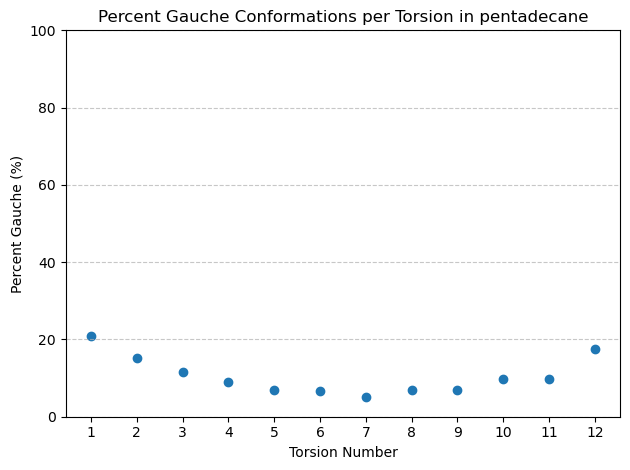

In [7]:
import matplotlib.pyplot as plt

# Determine number of dihedrals
num_dihedrals = angles_deg.shape[1]

# Store percent gauche for each torsion
percent_gauche = []

for i in range(num_dihedrals):
    column_name = f'dihedral {i+1} classified'
    gauche_count = df[column_name].value_counts().get('gauche', 0)
    percent = (gauche_count / len(df)) * 100
    percent_gauche.append(percent)

# Plotting
# plt.figure(figsize=(8, 5))
plt.scatter(range(1, num_dihedrals + 1), percent_gauche)
plt.xlabel("Torsion Number")
plt.ylabel("Percent Gauche (%)")
plt.title(f"Percent Gauche Conformations per Torsion in {mol}")
plt.xticks(range(1, num_dihedrals + 1))
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [8]:
# Total number of frames and dihedrals
n_frames = len(df)
n_dihedrals = angles_deg.shape[1]

# Total gauche and trans counts
gauche_total = 0
trans_total = 0

for i in range(n_dihedrals):
    col = f'dihedral {i+1} classified'
    value_counts = df[col].value_counts()
    gauche_total += value_counts.get("gauche", 0)
    trans_total += value_counts.get("trans", 0)

# Normalize to number of torsions (so max total = n_dihedrals) Not necessary and I dont think Lipid14 does this in their paper but Im not 100%
normalized_gauche = gauche_total / n_frames
normalized_trans = trans_total / n_frames


print(f"Normalized gauche: {normalized_gauche:.3f}")
print(f"Normalized trans: {normalized_trans:.3f}")
print(f"t/g ratio: {normalized_trans/normalized_gauche}")
print(f"Check (should sum to {n_dihedrals}): {normalized_gauche + normalized_trans:.3f}")


Normalized gauche: 1.262
Normalized trans: 10.738
t/g ratio: 8.505279831045407
Check (should sum to 12): 12.000
